# **51. 가장 가까운 같은 글자(250117)**

In [ ]:
# 문제 설명
# 문자열 s가 주어졌을 때, s의 각 위치마다 자신보다 앞에 나왔으면서,
# 자신과 가장 가까운 곳에 있는 같은 글자가 어디 있는지 알고 싶습니다.
# 예를 들어, s="banana"라고 할 때,  각 글자들을 왼쪽부터 오른쪽으로 읽어 나가면서 다음과 같이 진행할 수 있습니다.

# b는 처음 나왔기 때문에 자신의 앞에 같은 글자가 없습니다. 이는 -1로 표현합니다.
# a는 처음 나왔기 때문에 자신의 앞에 같은 글자가 없습니다. 이는 -1로 표현합니다.
# n은 처음 나왔기 때문에 자신의 앞에 같은 글자가 없습니다. 이는 -1로 표현합니다.
# a는 자신보다 두 칸 앞에 a가 있습니다. 이는 2로 표현합니다.
# n도 자신보다 두 칸 앞에 n이 있습니다. 이는 2로 표현합니다.
# a는 자신보다 두 칸, 네 칸 앞에 a가 있습니다. 이 중 가까운 것은 두 칸 앞이고, 이는 2로 표현합니다.
# 따라서 최종 결과물은 [-1, -1, -1, 2, 2, 2]가 됩니다.

# 문자열 s이 주어질 때, 위와 같이 정의된 연산을 수행하는 함수 solution을 완성해주세요.

# 제한사항
# 1 ≤ s의 길이 ≤ 10,000
# s은 영어 소문자로만 이루어져 있습니다.

# 입출력 예
# s	result
# "banana"	[-1, -1, -1, 2, 2, 2]
# "foobar"	[-1, -1, 1, -1, -1, -1]

# 입출력 예 설명

# 입출력 예 #1
# 지문과 같습니다.

# 입출력 예 #2
# 설명 생략

1) 내가 쓴 답

In [ ]:
def solution(s):
    answer = []
    words = ''
    for i, word in enumerate(s):
      if i == 0:
        answer.append(-1)
        words += word
      elif word in words:
        answer.append(words[::-1].find(word)+1)
        words += word
      elif word not in words:
        answer.append(words.find(word))
        words += word
    return answer

In [ ]:
s = "foobar"

In [ ]:
solution(s)

[-1, -1, 1, -1, -1, -1]

2) gpt가 쓴 답

In [ ]:
def solution(s):
    answer = []  # 결과를 저장할 리스트
    last_seen = {}  # 각 문자의 마지막 등장 위치를 저장하는 딕셔너리

    for i, char in enumerate(s):  # 문자열의 각 문자를 인덱스와 함께 순회
        if char in last_seen:  # 문자가 이전에 등장한 적이 있는 경우
            answer.append(i - last_seen[char])  # 현재 위치와 마지막 등장 위치의 차이를 계산하여 추가
        else:  # 문자가 처음 등장한 경우
            answer.append(-1)  # -1을 추가
        last_seen[char] = i  # 현재 문자의 위치를 딕셔너리에 저장 (마지막으로 등장한 위치)

    return answer  # 결과 리스트 반환

# **52. 카펫(250118)**(오답)

문제 설명

Leo는 카펫을 사러 갔다가 아래 그림과 같이 중앙에는 노란색으로 칠해져 있고 테두리 1줄은 갈색으로 칠해져 있는 격자 모양 카펫을 봤습니다.

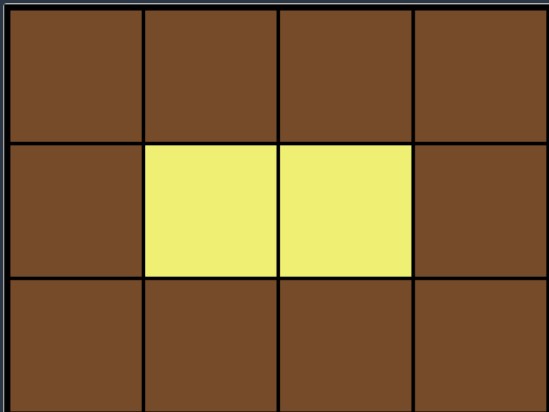

Leo는 집으로 돌아와서 아까 본 카펫의 노란색과 갈색으로 색칠된 격자의 개수는 기억했지만, 전체 카펫의 크기는 기억하지 못했습니다.

Leo가 본 카펫에서 갈색 격자의 수 brown, 노란색 격자의 수 yellow가 매개변수로 주어질 때 카펫의 가로, 세로 크기를 순서대로 배열에 담아 return 하도록 solution 함수를 작성해주세요.

제한사항

갈색 격자의 수 brown은 8 이상 5,000 이하인 자연수입니다.

노란색 격자의 수 yellow는 1 이상 2,000,000 이하인 자연수입니다.

카펫의 가로 길이는 세로 길이와 같거나, 세로 길이보다 깁니다.

입출력 예

brown	yellow	return

10	2	[4, 3]

8	1	[3, 3]

24	24	[8, 6]

1) 내가 쓴 답 - 오답

In [ ]:
def solution(brown, yellow):
    answer = []
    total = brown + yellow
    for i in range(1, total+1):
      for j in range(1, total+1):
        if i >= j and total%i == 0 and total&j == 0 and (i-2)*(j-2) == yellow:
          answer.append(i)
          answer.append(j)
    return answer

In [ ]:
solution(8, 1)

[]

2) gpt가 제안한 답

In [ ]:
def solution(brown, yellow):
    total = brown + yellow  # 전체 격자의 수 계산
    for i in range(1, int(total ** 0.5) + 1):  # i는 total의 제곱근까지만 탐색 (작은 약수)
        if total % i == 0:  # i가 total의 약수인지 확인
            j = total // i  # j는 i에 대한 대응 약수 (큰 약수)
            if (i - 2) * (j - 2) == yellow:  # 테두리를 제외한 내부 면적이 yellow와 같은지 확인
                return [j, i]  # 가로(j) ≥ 세로(i)를 반환 (항상 조건 충족)

# **53. 두개 뽑아서 더하기(250119)**

In [ ]:
# 문제 설명
# 정수 배열 numbers가 주어집니다. numbers에서 서로 다른 인덱스에 있는 두 개의 수를 뽑아 더해서 만들 수 있는
# 모든 수를 배열에 오름차순으로 담아 return 하도록 solution 함수를 완성해주세요.

# 제한사항
# numbers의 길이는 2 이상 100 이하입니다.
# numbers의 모든 수는 0 이상 100 이하입니다.

# 입출력 예
# numbers	result
# [2,1,3,4,1]	[2,3,4,5,6,7]
# [5,0,2,7]	[2,5,7,9,12]

# 입출력 예 설명

# 입출력 예 #1
# 2 = 1 + 1 입니다. (1이 numbers에 두 개 있습니다.)
# 3 = 2 + 1 입니다.
# 4 = 1 + 3 입니다.
# 5 = 1 + 4 = 2 + 3 입니다.
# 6 = 2 + 4 입니다.
# 7 = 3 + 4 입니다.
# 따라서 [2,3,4,5,6,7] 을 return 해야 합니다.

# 입출력 예 #2
# 2 = 0 + 2 입니다.
# 5 = 5 + 0 입니다.
# 7 = 0 + 7 = 5 + 2 입니다.
# 9 = 2 + 7 입니다.
# 12 = 5 + 7 입니다.
# 따라서 [2,5,7,9,12] 를 return 해야 합니다.

1) 내가 쓴 코드

In [ ]:
def solution(numbers):
    answer = []
    for i in range(len(numbers)):  # 배열의 모든 인덱스를 순회
        for j in range(i + 1, len(numbers)):  # i+1부터 시작해 중복을 방지
            answer.append(numbers[i] + numbers[j])  # 두 숫자의 합을 리스트에 추가
    return sorted(set(answer))  # 중복 제거 후 오름차순 정렬

In [ ]:
numbers = [5,0,2,7]

In [ ]:
solution(numbers)

[2, 5, 7, 9, 12]

2) gpt가 쓴 답

In [ ]:
from itertools import combinations  # 조합을 생성하는 라이브러리

def solution(numbers):
    # 두 수의 합을 계산하고 중복 제거(set) 후 정렬(sorted)
    return sorted(set(a + b for a, b in combinations(numbers, 2)))

# **54. 숫자 문자열과 영단어(250120)**


In [ ]:
# 네오와 프로도가 숫자놀이를 하고 있습니다. 네오가 프로도에게 숫자를 건넬 때
# 일부 자릿수를 영단어로 바꾼 카드를 건네주면 프로도는 원래 숫자를 찾는 게임입니다.

# 다음은 숫자의 일부 자릿수를 영단어로 바꾸는 예시입니다.

# 1478 → "one4seveneight"
# 234567 → "23four5six7"
# 10203 → "1zerotwozero3"
# 이렇게 숫자의 일부 자릿수가 영단어로 바뀌어졌거나, 혹은 바뀌지 않고 그대로인 문자열 s가 매개변수로 주어집니다.
# s가 의미하는 원래 숫자를 return 하도록 solution 함수를 완성해주세요.

# 참고로 각 숫자에 대응되는 영단어는 다음 표와 같습니다.

# 숫자	영단어
# 0	zero
# 1	one
# 2	two
# 3	three
# 4	four
# 5	five
# 6	six
# 7	seven
# 8	eight
# 9	nine

# 제한사항
# 1 ≤ s의 길이 ≤ 50
# s가 "zero" 또는 "0"으로 시작하는 경우는 주어지지 않습니다.
# return 값이 1 이상 2,000,000,000 이하의 정수가 되는 올바른 입력만 s로 주어집니다.

# 입출력 예
# s	result
# "one4seveneight"	1478
# "23four5six7"	234567
# "2three45sixseven"	234567
# "123"	123

# 입출력 예 설명
# 입출력 예 #1
# 문제 예시와 같습니다.
# 입출력 예 #2
# 문제 예시와 같습니다.
# 입출력 예 #3
# "three"는 3, "six"는 6, "seven"은 7에 대응되기 때문에 정답은 입출력 예 #2와 같은 234567이 됩니다.
# 입출력 예 #2와 #3과 같이 같은 정답을 가리키는 문자열이 여러 가지가 나올 수 있습니다.
# 입출력 예 #4
# s에는 영단어로 바뀐 부분이 없습니다.

# 제한시간 안내
# 정확성 테스트 : 10초

1) 내가 쓴 답

In [ ]:
def solution(s):
    num = {'zero':'0', 'one':'1', 'two':'2', 'three':'3', 'four':'4', 'five':'5', 'six':'6', 'seven':'7', 'eight':'8', 'nine':'9'}
    stack = ''
    answer = ''
    for a in s:
      if a.isalpha():
        stack += a
        if stack in num:
          answer += num[stack]
          stack = ''
      else:
        answer += a
    return int(answer)

In [ ]:
s = "23four5six7"

In [ ]:
solution(s)

234567

2) gpt가 제안한 답

(1)

In [ ]:
def solution(s):
    # 숫자 단어와 숫자 매핑
    num = {'zero': '0', 'one': '1', 'two': '2', 'three': '3', 'four': '4',
           'five': '5', 'six': '6', 'seven': '7', 'eight': '8', 'nine': '9'}

    # s의 단어를 순차적으로 숫자로 대체
    for word, digit in num.items():
        s = s.replace(word, digit)  # 해당 단어를 숫자로 변환

    return int(s)  # 문자열을 정수로 변환

1. for word, digit in num.items()는 딕셔너리 num에서 각 키-값 쌍을 순차적으로 가져옵니다.
 - word: num 딕셔너리의 키 (영단어, 예: "zero", "one", 등).
 - digit: num 딕셔너리의 값 (숫자 문자열, 예: "0", "1", 등).
2. replace는 문자열 내에서 특정 부분을 다른 값으로 치환하는 함수입니다. s.replace(word, digit)는 아래와 같이 작동합니다:
 - word(예: "zero")를 문자열 s에서 찾습니다.
 - word가 발견되면 이를 digit(예: "0")으로 대체합니다.
 - 문자열 s 전체를 순회하며 모든 word를 digit으로 대체합니다.

replace는 정확히 word와 동일한 부분만 대체하기 때문에 s의 문자 범위를 일일이 확인할 필요가 없습니다. 이 과정은 Python 내부적으로 효율적으로 처리됩니다.

(2)

In [ ]:
import re

def solution(s):
    # 숫자 단어와 숫자 매핑
    num = {'zero': '0', 'one': '1', 'two': '2', 'three': '3', 'four': '4',
           'five': '5', 'six': '6', 'seven': '7', 'eight': '8', 'nine': '9'}

    # 정규식을 사용하여 문자열에서 영단어를 숫자로 대체
    s = re.sub(r'zero|one|two|three|four|five|six|seven|eight|nine',
               lambda x: num[x.group()], s)

    return int(s)  # 문자열을 정수로 변환

In [ ]:
# 1. re 라이브러리란?
# re는 Python의 정규식(Regular Expression) 라이브러리입니다.
# 정규식은 문자열 패턴을 정의하여 텍스트 검색, 치환 등을 효율적으로 처리할 수 있습니다.

# 2. re.sub 함수란?
# re.sub(pattern, repl, string)은 특정 패턴에 맞는 문자열을 다른 문자열로 치환하는 함수입니다.

# 매개변수:
# 1. pattern: 치환 대상이 되는 정규식 패턴.
#  - 예: r'zero|one|two'는 "zero", "one", "two" 중 하나를 찾는 정규식입니다.
# 2. repl: 치환할 값 또는 처리 로직.
#  - 문자열 또는 함수가 올 수 있습니다.
#  - 함수일 경우, 매칭된 값마다 호출되어 새로운 값으로 치환할 수 있습니다.
# 3. string: 치환 작업을 수행할 원본 문자열.

# 반환값:
# re.sub는 치환이 완료된 새로운 문자열을 반환합니다.

# 3. 예시
# r'zero|one|two|...|nine':

# 정규식 패턴. |는 "OR"을 의미하며, zero 또는 one 또는 two 등의 단어를 찾습니다.
# r은 "raw string"으로, 문자열 내 특수 문자를 그대로 처리합니다.
# lambda x: num[x.group()]:

# x는 re.sub가 매칭된 값을 표현하는 객체입니다.
# x.group()은 매칭된 문자열 자체를 반환합니다.
# num[x.group()]은 num 딕셔너리에서 매칭된 단어에 해당하는 숫자 값을 가져옵니다.

# 예를 들어:
# s = "one4seveneight"이고, pattern = r'zero|one|...|nine'인 경우,
# "one"이 매칭됩니다. x.group()은 "one"을 반환.
# lambda는 num["one"]을 찾아 "1"로 대체합니다.
# re.sub는 문자열을 순차적으로 처리하며, 최종적으로 모든 매칭을 치환합니다.

# **55. 푸트 파이트 대회(250121)**

In [ ]:
def solution(food):
    answer = ''
    for i in range(1, len(food)):
      answer += (int(food[i])//2)*str(i)
    return answer + '0' + answer[::-1]

In [ ]:
def solution(food):
    answer = "0"  # 중앙에 위치한 물
    for i in range(len(food)-1, 0, -1):  # 음식 번호를 큰 번호부터 순회
        c = int(food[i] / 2)  # 해당 음식의 절반 개수 계산
        while c > 0:  # 절반 개수만큼 반복
            answer = str(i) + answer + str(i)  # 음식 번호를 양쪽에 추가
            c -= 1  # 남은 음식 개수 감소
    return answer  # 최종 결과 반환

In [ ]:
# food = [1, 7, 1, 2]
# for i in range(len(food)-1, 0, -1):
#     print(i)

# 동작 과정:
# len(food)는 4, 따라서 range(3, 0, -1)가 생성됩니다.
# range(3, 0, -1)는 [3, 2, 1]의 순서를 나타냅니다.
# 루프가 실행되며 i 값은 다음 순서로 할당됩니다:
# 첫 번째 반복: i = 3
# 두 번째 반복: i = 2
# 세 번째 반복: i = 1
# 0은 포함되지 않으므로 반복이 종료됩니다.

# **56. 문자열 내 마음대로 정렬하기(250122)**

In [ ]:
# 문제 설명
# 문자열로 구성된 리스트 strings와, 정수 n이 주어졌을 때, 각 문자열의 인덱스 n번째 글자를 기준으로 오름차순 정렬하려 합니다.
# 예를 들어 strings가 ["sun", "bed", "car"]이고 n이 1이면 각 단어의 인덱스 1의 문자 "u", "e", "a"로 strings를 정렬합니다.

# 제한 조건
# strings는 길이 1 이상, 50이하인 배열입니다.
# strings의 원소는 소문자 알파벳으로 이루어져 있습니다.
# strings의 원소는 길이 1 이상, 100이하인 문자열입니다.
# 모든 strings의 원소의 길이는 n보다 큽니다.
# 인덱스 1의 문자가 같은 문자열이 여럿 일 경우, 사전순으로 앞선 문자열이 앞쪽에 위치합니다.

# 입출력 예
# strings	n	return
# ["sun", "bed", "car"]	1	["car", "bed", "sun"]
# ["abce", "abcd", "cdx"]	2	["abcd", "abce", "cdx"]

# 입출력 예 설명
# 입출력 예 1
# "sun", "bed", "car"의 1번째 인덱스 값은 각각 "u", "e", "a" 입니다. 이를 기준으로 strings를 정렬하면 ["car", "bed", "sun"] 입니다.

# 입출력 예 2
# "abce"와 "abcd", "cdx"의 2번째 인덱스 값은 "c", "c", "x"입니다. 따라서 정렬 후에는 "cdx"가 가장 뒤에 위치합니다.
# "abce"와 "abcd"는 사전순으로 정렬하면 "abcd"가 우선하므로, 답은 ["abcd", "abce", "cdx"] 입니다.

1) 내가 쓴 답

In [ ]:
def solution(strings, n):
    d = {}
    for word in strings:
      d[word] = word[n]
    k = dict(sorted(d.items()))
    answer = dict(sorted(k.items(), key=lambda x: x[1]))
    return list(answer.keys())

In [ ]:
strings = ["abce", "abcd", "cdx"]

In [ ]:
solution(strings, 2)

['abcd', 'abce', 'cdx']

2) gpt가 쓴 답

In [ ]:
def solution(strings, n):
    # sorted()를 사용해 strings 리스트를 한 번에 정렬
    # 첫 번째 기준: n번째 문자
    # 두 번째 기준: 문자열 자체로 사전순 정렬
    return sorted(strings, key=lambda x: (x[n], x))

In [ ]:
# 개선 설명:
# 1. sorted()를 사용하여 문자열 리스트를 정렬합니다.
# 2. 정렬 기준은 key 매개변수로 지정한 튜플 (x[n], x):
#  - x[n]은 n번째 문자 기준으로 정렬합니다.
#  - 같은 문자의 경우, x 자체를 기준으로 사전순 정렬합니다.

# 리스트 sort()는 원본 리스트를 직접 변경합니다. 원본 데이터를 유지하고 싶다면 sorted()가 더 적합합니다.

# 요약: 쉼표(,)로 연결된 튜플 정렬
#  - sorted(strings, key=lambda x: (x[n], x))에서 (x[n], x)는 각 문자열을 정렬 기준으로 사용할 튜플을 생성합니다.
#  - Python은 튜플의 요소를 왼쪽에서 오른쪽으로 차례대로 비교하여 정렬합니다.
#  - 따라서 첫 번째 요소를 기준으로 정렬하고, 동일할 경우 두 번째 요소로 넘어가는 방식으로 작동합니다.

2) 다른 사람이 쓴 답

In [ ]:
from operator import itemgetter

def solution(strings, n):
    # 첫 번째 정렬: 사전순 정렬
    # 두 번째 정렬: n번째 문자 기준 정렬
    return sorted(sorted(strings), key=itemgetter(n))

In [ ]:
# 1. 정렬 과정:
#  - 먼저 sorted(strings)로 리스트를 사전순으로 정렬합니다.
#  - 이후 key=itemgetter(n)로 n번째 문자를 기준으로 다시 정렬합니다.

# 2. itemgetter(n):
#  - operator.itemgetter(n)는 입력 데이터의 n번째 요소를 반환합니다.
#  - 이 방식은 lambda x: x[n]과 동일한 결과를 제공하나, 성능이 약간 더 효율적입니다.

# 3. 장점:
#  - 사전순 정렬과 n번째 문자 기준 정렬을 분리하여 처리하므로 의도가 명확합니다.
#  - itemgetter는 성능 최적화에 유리합니다.

# 4. 단점:
#  - 두 번의 정렬을 수행하여 약간의 성능 저하가 있습니다.

# **57. K번째 수(250123)**

In [ ]:
# 문제 설명
# 배열 array의 i번째 숫자부터 j번째 숫자까지 자르고 정렬했을 때, k번째에 있는 수를 구하려 합니다.

# 예를 들어 array가 [1, 5, 2, 6, 3, 7, 4], i = 2, j = 5, k = 3이라면

# array의 2번째부터 5번째까지 자르면 [5, 2, 6, 3]입니다.
# 1에서 나온 배열을 정렬하면 [2, 3, 5, 6]입니다.
# 2에서 나온 배열의 3번째 숫자는 5입니다.
# 배열 array, [i, j, k]를 원소로 가진 2차원 배열 commands가 매개변수로 주어질 때,
# commands의 모든 원소에 대해 앞서 설명한 연산을 적용했을 때 나온 결과를 배열에 담아 return 하도록 solution 함수를 작성해주세요.

# 제한사항
# array의 길이는 1 이상 100 이하입니다.
# array의 각 원소는 1 이상 100 이하입니다.
# commands의 길이는 1 이상 50 이하입니다.
# commands의 각 원소는 길이가 3입니다.

# 입출력 예
# array	commands	return
# [1, 5, 2, 6, 3, 7, 4]	[[2, 5, 3], [4, 4, 1], [1, 7, 3]]	[5, 6, 3]

# 입출력 예 설명
# [1, 5, 2, 6, 3, 7, 4]를 2번째부터 5번째까지 자른 후 정렬합니다. [2, 3, 5, 6]의 세 번째 숫자는 5입니다.
# [1, 5, 2, 6, 3, 7, 4]를 4번째부터 4번째까지 자른 후 정렬합니다. [6]의 첫 번째 숫자는 6입니다.
# [1, 5, 2, 6, 3, 7, 4]를 1번째부터 7번째까지 자릅니다. [1, 2, 3, 4, 5, 6, 7]의 세 번째 숫자는 3입니다.

1) 내가 쓴 답

In [ ]:
def solution(array, commands):
    answer = []
    for i in range(len(commands)):
      s = sorted(array[commands[i][0]-1:commands[i][1]])
      answer.append(s[commands[i][2]-1])
    return answer

In [ ]:
array = [1, 5, 2, 6, 3, 7, 4]

In [ ]:
commands = [[2, 5, 3], [4, 4, 1], [1, 7, 3]]

In [ ]:
solution(array, commands)

[5, 6, 3]

2) 최적화 코드

In [ ]:
def solution(array, commands):
    # 결과를 저장할 리스트 생성
    answer = []

    # commands 리스트에서 각 명령을 하나씩 처리
    for command in commands:
        # command 배열에서 i, j, k 값을 각각 추출
        i, j, k = command

        # array의 i번째부터 j번째까지 자르고 정렬 후 k번째 숫자 선택
        answer.append(sorted(array[i-1:j])[k-1])

    return answer

3) gpt 제안 코드

In [ ]:
def solution(array, commands):
    # Python의 리스트 컴프리헨션을 활용해 간결하게 처리
    return [sorted(array[i-1:j])[k-1] for i, j, k in commands]

4) 다른 사람의 코드

In [ ]:
def solution(array, commands):
    # commands 리스트의 각 명령에 대해 lambda 함수를 사용해 처리
    return list(
        map(
            lambda x:
            # array에서 x[0]-1번째부터 x[1]번째까지 자른 후 정렬
            sorted(array[x[0]-1:x[1]])[x[2]-1],  # 정렬된 배열에서 x[2]-1 번째 값 반환
            commands # commands 리스트의 각 요소에 대해 반복
        )
    )

In [ ]:
# 코드 설명
# 이 코드는 Python의 map과 lambda를 활용해 주어진 commands 리스트의 각 명령을 처리하고, 결과를 리스트로 반환합니다.

# map 함수:

# map은 첫 번째 인자로 주어진 함수(lambda)를 commands의 각 요소에 적용합니다.
# 결과는 맵 객체로 반환되며, 이를 list()로 변환해 최종 결과 리스트를 만듭니다.
# lambda 함수:

# 익명 함수로, 각 x에 대해 다음 작업을 수행:
# x[0], x[1], x[2]는 각각 i, j, k에 해당합니다.
# array[x[0]-1:x[1]]로 array의 i번째부터 j번째까지 잘라내고, sorted()로 정렬합니다.
# 정렬된 배열의 x[2]-1 번째 값을 반환합니다.
# 리스트로 변환:

# map의 결과를 list()로 변환해 최종 결과를 반환합니다.

# **58. 콜라 문제(250127)**

In [ ]:
# 문제 설명
# 오래전 유행했던 콜라 문제가 있습니다. 콜라 문제의 지문은 다음과 같습니다.

# 정답은 아무에게도 말하지 마세요.

# 콜라 빈 병 2개를 가져다주면 콜라 1병을 주는 마트가 있다. 빈 병 20개를 가져다주면 몇 병을 받을 수 있는가?

# 단, 보유 중인 빈 병이 2개 미만이면, 콜라를 받을 수 없다.

# 문제를 풀던 상빈이는 콜라 문제의 완벽한 해답을 찾았습니다. 상빈이가 푼 방법은 아래 그림과 같습니다.
# 우선 콜라 빈 병 20병을 가져가서 10병을 받습니다. 받은 10병을 모두 마신 뒤, 가져가서 5병을 받습니다.
# 5병 중 4병을 모두 마신 뒤 가져가서 2병을 받고, 또 2병을 모두 마신 뒤 가져가서 1병을 받습니다.
# 받은 1병과 5병을 받았을 때 남은 1병을 모두 마신 뒤 가져가면 1병을 또 받을 수 있습니다.
# 이 경우 상빈이는 총 10 + 5 + 2 + 1 + 1 = 19병의 콜라를 받을 수 있습니다.

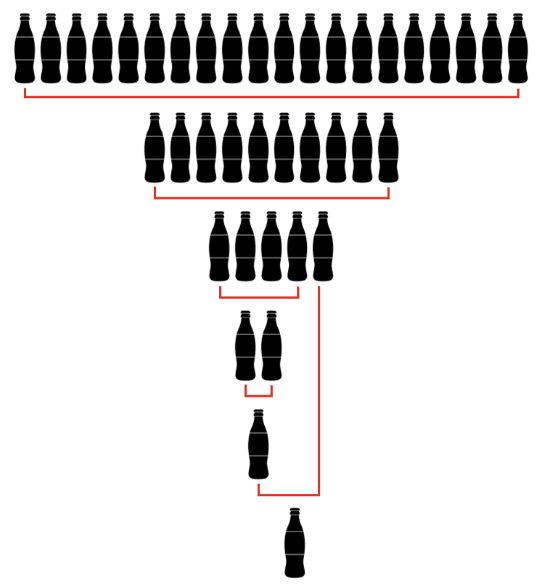

In [ ]:
# 문제를 열심히 풀던 상빈이는 일반화된 콜라 문제를 생각했습니다.
# 이 문제는 빈 병 a개를 가져다주면 콜라 b병을 주는 마트가 있을 때, 빈 병 n개를 가져다주면 몇 병을 받을 수 있는지 계산하는 문제입니다.
# 기존 콜라 문제와 마찬가지로, 보유 중인 빈 병이 a개 미만이면, 추가적으로 빈 병을 받을 순 없습니다.
# 상빈이는 열심히 고심했지만, 일반화된 콜라 문제의 답을 찾을 수 없었습니다. 상빈이를 도와, 일반화된 콜라 문제를 해결하는 프로그램을 만들어 주세요.

# 콜라를 받기 위해 마트에 주어야 하는 병 수 a, 빈 병 a개를 가져다 주면 마트가 주는 콜라 병 수 b,
# 상빈이가 가지고 있는 빈 병의 개수 n이 매개변수로 주어집니다.
# 상빈이가 받을 수 있는 콜라의 병 수를 return 하도록 solution 함수를 작성해주세요.

# 제한사항
# 1 ≤ b < a ≤ n ≤ 1,000,000
# 정답은 항상 int 범위를 넘지 않게 주어집니다.

# 입출력 예
# a	b	n	result
# 2	1	20	19
# 3	1	20	9

# 입출력 예 설명
# 입출력 예 #1
# 본문에서 설명한 예시입니다.
# 입출력 예 #2
# 빈 병 20개 중 18개를 마트에 가져가서, 6병의 콜라를 받습니다. 이때 상빈이가 가지고 있는 콜라 병의 수는 8(20 – 18 + 6 = 8)개 입니다.
# 빈 병 8개 중 6개를 마트에 가져가서, 2병의 콜라를 받습니다. 이때 상빈이가 가지고 있는 콜라 병의 수는 4(8 – 6 + 2 = 4)개 입니다.
# 빈 병 4 개중 3개를 마트에 가져가서, 1병의 콜라를 받습니다. 이때 상빈이가 가지고 있는 콜라 병의 수는 2(4 – 3 + 1 = 2)개 입니다.
# 3번의 교환 동안 상빈이는 9(6 + 2 + 1 = 9)병의 콜라를 받았습니다.

1) 내 코드

In [1]:
def solution(a, b, n):
    answer = 0
    while n >= a:
        answer += (n//a)*b
        n = n - (n//a)*a + (n//a)*b
    return answer

In [2]:
solution(2, 1, 20)

19

2) 최적 개선된 코드

In [ ]:
def solution(a, b, n):
    answer = 0
    while n >= a:
        # 현재 교환 가능한 병의 개수 계산
        exchange = n // a
        # 받은 콜라 병의 수를 누적
        answer += exchange * b
        # 현재 보유 병 수를 업데이트
        n = n % a + exchange * b
    return answer